<a href="https://colab.research.google.com/github/felipebrsm/PUC_Sprint_1_ML-FBRSM/blob/main/notebook/MVP_FBRSM_PUC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#MVP: *Machine Learning & Analytics*

Modelo de Classificação de Dados Geotécnicos por *Random Forest* e *K-Means*

**Autor:** Felipe Barreto R. S. Macedo

**Data:** 05/07/2026

**Matrícula:** XXXXX

**Dataset:** Ex: Global Dataset of Cone Penetration Test Results - Jianye Ching (http://140.112.12.21/issmge/Database/Global_CPT_3_1196/Global_CPT_3_1196.zip)


---



## ✅ Checklist do MVP (o que precisa conter)
- [ ] **Problema definido** e contexto de negócio
- [ ] **Carga e preparação** dos dados (sem vazamento de dados)
- [ ] **Divisão** em treino/validação/teste (ou validação cruzada apropriada)
- [ ] **Tratamento**: limpeza, transformação e **engenharia de atributos**
- [ ] **Modelagem**: comparar abordagens/modelos (com **baseline**)
- [ ] **Otimização de hiperparâmetros**
- [ ] **Avaliação** com **métricas adequadas** e discussão de limitações
- [ ] **Boas práticas**: seeds fixas, tempo de treino, recursos computacionais, documentação
- [ ] **Pipelines reprodutíveis** (sempre que possível)



## 1. Escopo, objetivo e definição do problema

A classificação de tipos de solo é de fundamental importância para a Engenharia Geotécnica, sendo o ensaio de Penetração de Cone Piezométrico (CPT) uma das formas mais confiáveis de obtenção de dados subterrâneos, em particular para projetos submarinos.

O resultado do CPT fornece parâmetros que permitem avaliar granulometria do solo e calcular valores de resistência ao cisalhamento. Usualmente, é utilizado o método empírico de Robertson para classificação de solos (Soil Behavior Type), embora esse modelo seja generalista, muitas vezes não permitindo a avaliação de mudanças de comportamento local.

A proposta desse MVP é a criação de modelos que permitam:
- classificar camadas de solo a partir dos parâmetros do CPT;
- detecte interfaces em camadas;
- comparar com o modelo de Robertson, avaliando concordâncias, discordâncias e abrangência.

Para tanto, foi utilizado um dataset de resultados globais de CPT disponibilizado na internet. Os dados estão divididos por locação, organizados em planilhas .xlsx, e apresentam os parâmetros usuais de resultados de CPT:
- depth - Profundidade (m)
- qc - Resistência de ponta (MPa)
- fs - Atrito lateral (kPa)
- u2 - Poropressão (kPa)

Foram previstas as seguintes etapas:
1. Pré-processamento com compilação, padronização e normalização dos dados.
2. *Feature Engineering* com cálculo das tensões in-situ e dos índices normalizados.
3. Classificação supervisionada pelo modelo de Robertson (parâmetro Ic), servindo de base para a comparação dos modelos.
4. Modelagem não supervisionada por K-Means, com escolha de k por meio do Silhouette Score e método do cotovelo.
5. Modelagem por Random Forest supervisionada pelo método de Robertson, possibilitando predição e indicando a importância de cada feature.
6. Comparação entre K-Means, Random Forest e Robertson.

Como resultado, proponho um log CPT classificado para furos de teste, acompanhado de uma tabela de métricas comparando os dois modelos com Robertson — permitindo avaliar quantitativamente o quanto a classificação automática converge ou diverge do método tradicional.





## 2. Reprodutibilidade e ambiente
Especifique o ambiente. Por exemplo:
- Bibliotecas usadas.
- Seeds fixas para reprodutibilidade.

In [20]:
# ---- CÓDIGO REAL ----------#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, adjusted_rand_score, silhouette_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.



### 2.1 Dependências (opcional)
Instale pacotes extras se necessário. **Mantenha o projeto enxuto** para facilitar a correção.


2.1.a Instalações

In [1]:
!pip install -q imbalanced-learn shap scipy


2.1.a Bibliotecas

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.optimize import linear_sum_assignment

# Sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    GroupShuffleSplit, GroupKFold, cross_validate
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    cohen_kappa_score, f1_score, accuracy_score,
    silhouette_score, adjusted_rand_score,
    normalized_mutual_info_score, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# SHAP
import shap

# Utilitários
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
SEED = 42
np.random.seed(SEED)

print("✅ Imports concluídos com sucesso.")



✅ Imports concluídos com sucesso.



## 3. Dados: carga, entendimento e qualidade
**TODO:** descreva a origem dos dados, dicionário de variáveis e licença/ética quando aplicável.  
Evite **vazamento de dados**. Se usar feature store ou dados sintéticos, explique.


INCLUIR TEXTO EXPLICANDO PROCESSAMENTO

Leitura do Database

In [3]:
USUARIO = 'felipebrsm'
REPO    = 'PUC_Sprint_1_ML-FBRSM'
BRANCH  = 'main'
ARQUIVO = 'data/processed/dataset_compilado.csv'

URL = f'https://raw.githubusercontent.com/felipebrsm/PUC_Sprint_1_ML-FBRSM/refs/heads/main/data/processed/dataset_compilado.csv'

df = pd.read_csv(URL)

print(f'Shape: {df.shape}')
df.head()

Shape: (475083, 7)


,locacao,ensaio,pagina,depth,qc,fs,u2
0,@Aranui,1,工作表1,0.000000,0.4374,0.0,2.1
1,@Aranui,1,工作表1,0.010000,0.7282,0.0,2.1
2,@Aranui,1,工作表1,0.019999,0.6739,0.0,2.5
3,@Aranui,1,工作表1,0.029997,2.2015,0.0,2.3
4,@Aranui,1,工作表1,0.039996,2.6513,0.0,2.9


Resumo do Dataset

In [4]:

dataset = df

print('=' * 50)
print('RESUMO DO DATASET COMPILADO')
print('=' * 50)
print(f'Linhas totais  : {len(dataset):,}')
print(f'Locações       : {dataset["locacao"].nunique()}')
print(f'Ensaios únicos : {dataset[["locacao","ensaio"]].drop_duplicates().shape[0]}')
print(f'Abas únicas    : {dataset[["locacao","ensaio","pagina"]].drop_duplicates().shape[0]}')
print()
print('Ensaios por locação:')
print(dataset.groupby('locacao')['ensaio'].nunique().to_string())

RESUMO DO DATASET COMPILADO
Linhas totais  : 475,083
Locações       : 23
Ensaios únicos : 412
Abas únicas    : 412

Ensaios por locação:
locacao
@Aranui                                   11
@Avondale                                 33
@Avonside                                 12
@Bexley                                   14
@Camberley (hospital)                     12
@Cashmere (high school)                   16
@Christchurch (Central City)              36
@Christchurch (Cnr Armagh & Durham St)     6
@Christchurch (Metro Sports Facility)     15
@Christchurch (stadium)                   12
@Hastings (hospital)                      13
@Lower Hutt (town hall)                   29
@Marshland                                24
@Marshland (road)                         27
@New Brighton (Willryan Ave)              10
@Parkland (Bower Ave)ONE                   8
@Parkland (Bower Ave)TWO                  11
@Port Nelson                              27
@Redcliffs (Main road)                     7


Estatísticas

In [5]:
print('ESTATÍSTICAS DESCRITIVAS')
print(dataset[['depth','qc','fs','u2']].describe().round(3))
print()
print('VALORES NULOS')
nulos = dataset.isnull().sum()
print(nulos[nulos > 0] if nulos.any() else 'Nenhum valor nulo.')
print()
dataset.head()

ESTATÍSTICAS DESCRITIVAS
            depth          qc          fs           u2
count  475083.000  475083.000  472984.000   475083.000
mean        8.814       9.561      76.103      194.899
std         6.965       9.088     167.652    35535.280
min         0.000      -0.249   -7777.000   -90470.000
25%         3.487       2.140      27.700      -20.500
50%         6.993       6.950      56.500       14.000
75%        12.735      14.777      99.700       72.000
max       824.000      94.360    1674.000  9999000.000

VALORES NULOS
fs    2099
dtype: int64



,locacao,ensaio,pagina,depth,qc,fs,u2
0,@Aranui,1,工作表1,0.000000,0.4374,0.0,2.1
1,@Aranui,1,工作表1,0.010000,0.7282,0.0,2.1
2,@Aranui,1,工作表1,0.019999,0.6739,0.0,2.5
3,@Aranui,1,工作表1,0.029997,2.2015,0.0,2.3
4,@Aranui,1,工作表1,0.039996,2.6513,0.0,2.9


Limpeza

In [6]:
# Remove primeiros 0.5m (fs frequentemente zerado por falta de contato)
df = df[df['depth'] >= 0.5].copy()

# Clipa valores negativos de fs (erro de medição)
df['fs'] = df['fs'].clip(lower=0)

# Remove qc <= 0 (fisicamente impossível)
df = df[df['qc'] > 0].copy()

print(f'Linhas após limpeza: {len(df):,}')

Linhas após limpeza: 461,938


Avaliação visual do balanceamento

Estratégia de Balanceamento

## 6. Feature Engineering

Cálculo das tensões in situ e dos índices normalizados de Robertson (Qt, Fr, Bq, Ic), que removem o efeito do aumento de tensão com a profundidade.

In [8]:

def compute_cpt_features(df, gamma_soil=18.0, gamma_w=9.81, u0_grad=9.81):
    """
    Calcula variáveis normalizadas CPT e índice de comportamento Ic (Robertson 2010).

    Parâmetros:
    -----------
    gamma_soil : peso específico do solo (kN/m³) — assumido constante
    gamma_w    : peso específico da água (kN/m³)
    u0_grad    : gradiente de pressão hidrostática (kN/m³)

    Variáveis calculadas:
    - sigma_v0  : tensão vertical total (kPa)
    - sigma_v0p : tensão vertical efetiva (kPa)
    - u0        : pressão de poros hidrostática (kPa)
    - qt        : resistência de ponta corrigida (MPa)
    - Qt        : resistência normalizada (adim.)
    - Fr        : razão de atrito normalizada (%)
    - Bq        : parâmetro de pressão de poros (adim.)
    - Ic        : índice de comportamento do solo (Robertson 2010)
    """
    df = df.copy()

    # Tensões geostáticas
    df['sigma_v0']  = df['depth'] * gamma_soil                        # kPa
    df['u0']        = df['depth'] * u0_grad                           # kPa
    df['sigma_v0p'] = (df['sigma_v0'] - df['u0']).clip(lower=1.0)     # kPa efetivo

    # qt corrigido (simplificado: qt ≈ qc para solos drenados)
    df['qt'] = df['qc'] * 1000.0   # MPa → kPa

    # Variáveis normalizadas de Robertson
    df['Qt'] = (df['qt'] - df['sigma_v0']) / df['sigma_v0p']
    df['Qt'] = df['Qt'].clip(lower=0.1)

    df['Fr'] = (df['fs'] * 1000.0) / (df['qt'] - df['sigma_v0'] + 1e-6) * 100.0
    df['Fr'] = df['Fr'].clip(lower=0.01, upper=20.0)

    df['Bq'] = (df['u2'] - df['u0']) / (df['qt'] - df['sigma_v0'] + 1e-6)
    df['Bq'] = df['Bq'].clip(lower=-0.5, upper=2.0)

    # Ic — Robertson (2010): iterativo (simplificado com n=1 → SBTn)
    df['Ic'] = np.sqrt(
        (3.47 - np.log10(df['Qt'].clip(lower=0.1))) ** 2 +
        (np.log10(df['Fr'].clip(lower=0.1)) + 1.22) ** 2
    )

    return df


df_feat = compute_cpt_features(df)

print("✅ Features calculadas.")
print(df_feat[['depth', 'Qt', 'Fr', 'Bq', 'Ic']].describe().round(3))


✅ Features calculadas.
            depth          Qt          Fr          Bq          Ic
count  461938.000  461938.000  459839.000  461938.000  459839.000
mean        9.057     208.384      19.907       0.012       2.955
std         6.910     304.604       1.340       0.143       0.319
min         0.500       0.100       0.010      -0.500       0.221
25%         3.755      41.635      20.000      -0.017       2.743
50%         7.228     133.667      20.000      -0.005       2.856
75%        12.958     242.628      20.000      -0.001       3.125
max       824.000   10629.490      20.000       2.000       5.132


# ║  CÉLULA 5 — DEFINIÇÃO DE FEATURES E TARGET              ║


In [10]:

def robertson_classify(Ic, Bq=None):
    """
    Classificação pelo índice Ic (Robertson 2010).
    Bq usado como discriminador secundário para Zonas 1/2.
    Retorna zona (int) de 1 a 9.
    """
    if Ic > 3.60:
        return 1   # Turfa / solos altamente sensitivos
    elif Ic > 2.95:
        return 2   # Argilas orgânicas — OCST
    elif Ic > 2.60:
        return 3   # Argilas — CL a CH
    elif Ic > 2.05:
        return 4   # Silte argiloso — ML a CL
    elif Ic > 1.31:
        return 5   # Misturas areia-silte — ML a SM
    else:
        if Bq is not None and Bq > 0.0:
            return 7  # Areia com excesso de poros
        return 6       # Areias limpas — SP a SW

# Aplicar classificação Robertson
df_feat['zone_robertson'] = df_feat.apply(
    lambda r: robertson_classify(r['Ic'], r['Bq']), axis=1
)

# Verificar concordância com ground truth
concordancia = (df_feat['zone_robertson'] == df_feat['zone_robertson_true']).mean()
print(f"🎯 Concordância Robertson (baseline) com ground truth: {concordancia:.1%}")
print("\nDistribuição classes Robertson calculadas:")
print(df_feat['zone_robertson'].value_counts().sort_index())



Distribuição classes Robertson calculadas:
zone_robertson
1     24062
2    144786
3    267711
4     22507
5       432
6      2279
7       161
Name: count, dtype: int64


# ║  CÉLULA 6 — BALANCEAMENTO              ║


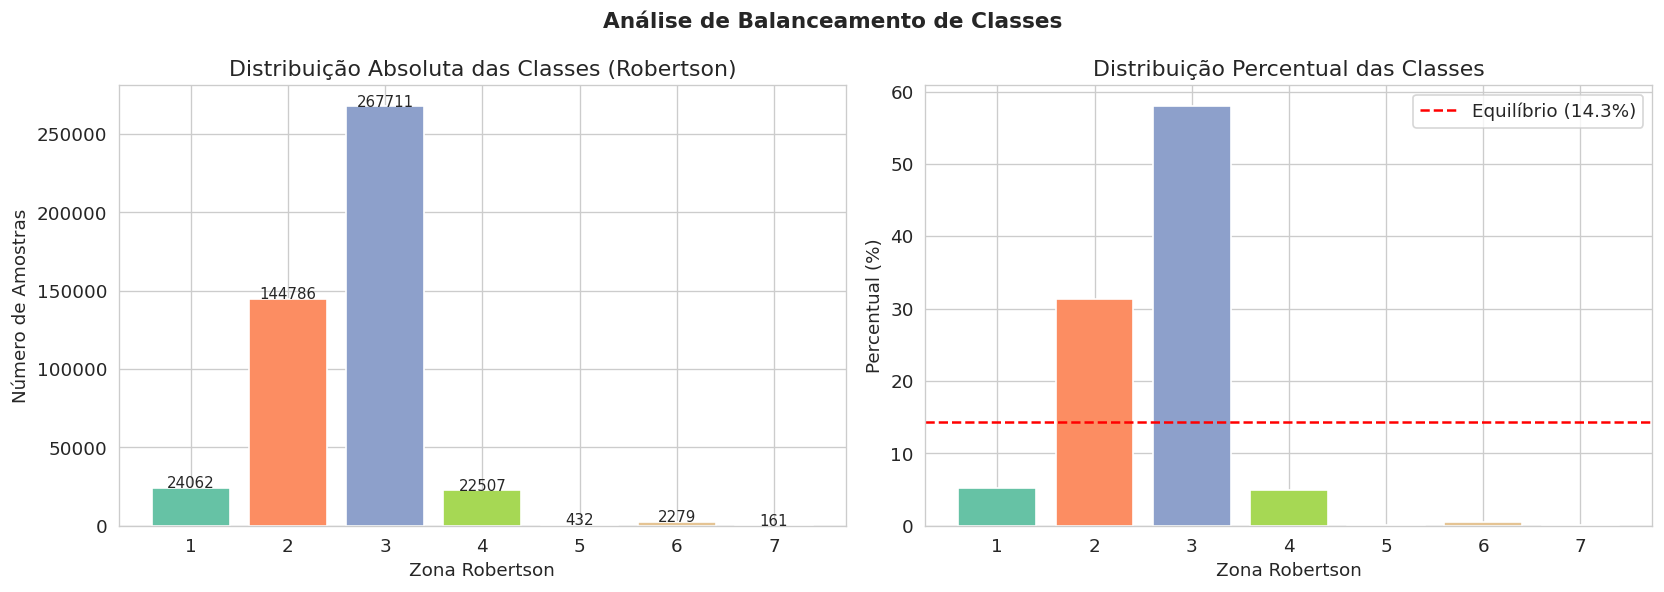


📊 Razão máx/mín de desbalanceamento: 1662.8x
→ Será aplicado class_weight='balanced' no RF e SMOTE no treino.


In [11]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição absoluta
counts = df_feat['zone_robertson'].value_counts().sort_index()
axes[0].bar(counts.index.astype(str), counts.values,
            color=plt.cm.Set2(np.linspace(0, 1, len(counts))))
axes[0].set_title('Distribuição Absoluta das Classes (Robertson)')
axes[0].set_xlabel('Zona Robertson')
axes[0].set_ylabel('Número de Amostras')
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

# Distribuição percentual com linha de equilíbrio
pct = counts / counts.sum() * 100
axes[1].bar(pct.index.astype(str), pct.values,
            color=plt.cm.Set2(np.linspace(0, 1, len(pct))))
axes[1].axhline(y=100/len(pct), color='red', linestyle='--',
                label=f'Equilíbrio ({100/len(pct):.1f}%)')
axes[1].set_title('Distribuição Percentual das Classes')
axes[1].set_xlabel('Zona Robertson')
axes[1].set_ylabel('Percentual (%)')
axes[1].legend()

plt.suptitle('Análise de Balanceamento de Classes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Razão de desbalanceamento
max_count = counts.max()
min_count = counts.min()
print(f"\n📊 Razão máx/mín de desbalanceamento: {max_count/min_count:.1f}x")
print("→ Será aplicado class_weight='balanced' no RF e SMOTE no treino.")


# ║  CÉLULA 7 — JANELAS MÓVEIS              ║


```
# This is formatted as code
```



In [13]:

def add_rolling_features(df, windows=[3, 7, 15]):
    """
    Adiciona estatísticas de janelas móveis POR FURO (respeitando grupos).
    Janelas capturem transições litológicas sem vazar entre furos.

    Features geradas: média e desvio padrão de qc e fs
    para cada tamanho de janela.
    """
    df = df.copy()

    # Create a unique borehole ID if not already present
    if 'borehole_id' not in df.columns:
        df['borehole_id'] = df['locacao'].astype(str) + '_' + df['ensaio'].astype(str)

    df = df.sort_values(['borehole_id', 'depth'])

    for w in windows:
        for col in ['qc', 'fs', 'Qt', 'Fr']:
            # Aplicar rolling dentro de cada furo separadamente
            df[f'{col}_roll{w}_mean'] = (
                df.groupby('borehole_id')[col]
                .transform(lambda x: x.rolling(w, center=True, min_periods=1).mean())
            )
            df[f'{col}_roll{w}_std'] = (
                df.groupby('borehole_id')[col]
                .transform(lambda x: x.rolling(w, center=True, min_periods=1).std())
                .fillna(0)
            )

    # Gradiente vertical (diferença entre leituras consecutivas por furo)
    for col in ['qc', 'fs']:
        df[f'{col}_gradient'] = (
            df.groupby('borehole_id')[col]
            .transform(lambda x: x.diff().fillna(0))
        )

    return df


df_feat = add_rolling_features(df_feat, windows=[3, 7, 15])

rolling_cols = [c for c in df_feat.columns if 'roll' in c or 'gradient' in c]
print(f"✅ {len(rolling_cols)} features de janela móvel adicionadas.")
print(f"   Total de features no dataset: {df_feat.shape[1]} colunas")


✅ 26 features de janela móvel adicionadas.
   Total de features no dataset: 43 colunas


# ║  CÉLULA 8 — DEFINIÇÃO DE FEATURES E TARGET              ║


In [19]:
# Features para o MODELO SUPERVISIONADO (RF) — sem Ic, conforme decisão de projeto
FEATURES_RF = [
    # Variáveis normalizadas brutas (sem Ic)
    'Qt', 'Fr', 'Bq',
    # Profundidade normalizada
    'depth',
    # Rolling windows — qc
    'qc_roll3_mean', 'qc_roll3_std',
    'qc_roll7_mean', 'qc_roll7_std',
    'qc_roll15_mean', 'qc_roll15_std',
    # Rolling windows — fs
    'fs_roll3_mean', 'fs_roll3_std',
    'fs_roll7_mean', 'fs_roll7_std',
    'fs_roll15_mean', 'fs_roll15_std',
    # Rolling windows — Qt e Fr
    'Qt_roll7_mean', 'Qt_roll7_std',
    'Fr_roll7_mean', 'Fr_roll7_std',
    # Gradientes
    'qc_gradient', 'fs_gradient',
]

# Features para o MODELO NÃO SUPERVISIONADO (K-Means)
FEATURES_KMEANS = ['Qt', 'Fr', 'Bq']   # Mesmo espaço de Robertson para comparabilidade

TARGET = 'zone_robertson'
GROUPS = 'borehole_id'

# Verificar ausência de NaN
df_model = df_feat[FEATURES_RF + FEATURES_KMEANS + [TARGET, GROUPS, 'depth',
                                                      'Ic', 'qc', 'fs']].dropna()

X_rf     = df_model[FEATURES_RF].values
X_kmeans = df_model[FEATURES_KMEANS].values
y        = df_model[TARGET].values
groups   = df_model[GROUPS].values

print(f"✅ Shape final para modelagem: {X_rf.shape}")
print(f"   Classes únicas: {np.unique(y)}")
print(f"   Grupos (furos): {np.unique(groups)}")


✅ Shape final para modelagem: (459839, 26)
   Classes únicas: [1 2 3 4 5 6 7]
   Grupos (furos): ['@Aranui_1' '@Aranui_10' '@Aranui_11' '@Aranui_2' '@Aranui_3' '@Aranui_4'
 '@Aranui_5' '@Aranui_6' '@Aranui_7' '@Aranui_8' '@Aranui_9' '@Avondale_1'
 '@Avondale_10' '@Avondale_11' '@Avondale_12' '@Avondale_13'
 '@Avondale_14' '@Avondale_15' '@Avondale_16' '@Avondale_17'
 '@Avondale_18' '@Avondale_19' '@Avondale_2' '@Avondale_20' '@Avondale_21'
 '@Avondale_22' '@Avondale_23' '@Avondale_24' '@Avondale_25'
 '@Avondale_26' '@Avondale_27' '@Avondale_28' '@Avondale_29' '@Avondale_3'
 '@Avondale_30' '@Avondale_31' '@Avondale_32' '@Avondale_33' '@Avondale_4'
 '@Avondale_5' '@Avondale_6' '@Avondale_7' '@Avondale_8' '@Avondale_9'
 '@Avonside_1' '@Avonside_10' '@Avonside_11' '@Avonside_12' '@Avonside_2'
 '@Avonside_3' '@Avonside_4' '@Avonside_5' '@Avonside_6' '@Avonside_7'
 '@Avonside_8' '@Avonside_9' '@Bexley_1' '@Bexley_10' '@Bexley_11'
 '@Bexley_12' '@Bexley_13' '@Bexley_14' '@Bexley_2' '@Bexley_3

# ║  CÉLULA 9 — HOLDOUT           ║

In [20]:

# GroupShuffleSplit garante que furos inteiros vão para treino ou teste
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, test_idx = next(gss.split(X_rf, y, groups=groups))

X_train_rf, X_test_rf = X_rf[train_idx], X_rf[test_idx]
X_train_km, X_test_km = X_kmeans[train_idx], X_kmeans[test_idx]
y_train, y_test       = y[train_idx], y[test_idx]
groups_train          = groups[train_idx]

# Verificar separação dos grupos
train_boreholes = set(groups[train_idx])
test_boreholes  = set(groups[test_idx])
assert len(train_boreholes & test_boreholes) == 0, "⚠️ Vazamento de grupos!"

print("✅ Holdout por grupo (furo) realizado com sucesso.")
print(f"   Furos de treino : {sorted(train_boreholes)}")
print(f"   Furos de teste  : {sorted(test_boreholes)}")
print(f"   Amostras treino : {len(X_train_rf)} ({len(X_train_rf)/len(X_rf):.1%})")
print(f"   Amostras teste  : {len(X_test_rf)} ({len(X_test_rf)/len(X_rf):.1%})")

# Distribuição de classes no treino vs teste
df_dist = pd.DataFrame({
    'Treino (%)': pd.Series(y_train).value_counts(normalize=True).sort_index() * 100,
    'Teste  (%)': pd.Series(y_test).value_counts(normalize=True).sort_index() * 100
}).round(1)
print("\nDistribuição de classes no split:")
print(df_dist)



✅ Holdout por grupo (furo) realizado com sucesso.
   Furos de treino : ['@Aranui_10', '@Aranui_11', '@Aranui_3', '@Aranui_5', '@Aranui_7', '@Aranui_9', '@Avondale_1', '@Avondale_10', '@Avondale_11', '@Avondale_12', '@Avondale_18', '@Avondale_19', '@Avondale_20', '@Avondale_23', '@Avondale_24', '@Avondale_25', '@Avondale_29', '@Avondale_30', '@Avondale_31', '@Avondale_32', '@Avondale_33', '@Avondale_4', '@Avondale_6', '@Avondale_7', '@Avondale_9', '@Avonside_1', '@Avonside_12', '@Avonside_2', '@Avonside_3', '@Avonside_4', '@Avonside_5', '@Avonside_6', '@Avonside_7', '@Avonside_8', '@Bexley_11', '@Bexley_12', '@Bexley_14', '@Bexley_2', '@Bexley_4', '@Bexley_5', '@Bexley_7', '@Bexley_8', '@Bexley_9', '@Camberley (hospital)_10', '@Camberley (hospital)_2', '@Camberley (hospital)_8', '@Camberley (hospital)_9', '@Cashmere (high school)_11', '@Cashmere (high school)_13', '@Cashmere (high school)_14', '@Cashmere (high school)_15', '@Cashmere (high school)_16', '@Cashmere (high school)_17', '@Ca

# ║  CÉLULA 10 — PIPELINE MODELO 1: RANDOM FOREST           ║


*   List item
*   List item



In [29]:

from imblearn.over_sampling import SMOTE


class SMOTESeguro(SMOTE):
    """Subclasse de SMOTE que verifica, antes de reamostrar, se a classe
    minoritária tem amostras suficientes para o k_neighbors definido.
    Caso não tenha, pula o oversampling e retorna os dados originais —
    evita que o fold quebre quando o GroupKFold deixa alguma classe
    rara abaixo do mínimo exigido pelo SMOTE.

    Herdar de SMOTE (em vez de implementar a interface do zero) garante
    compatibilidade total com os caminhos internos do imblearn.Pipeline,
    que dependem de atributos e métodos específicos da classe base."""

    def fit_resample(self, X, y):
        counts = pd.Series(y).value_counts()
        if counts.min() <= self.k_neighbors:
            # Amostras insuficientes — retorna sem oversampling
            return X, y
        return super().fit_resample(X, y)


pipeline_rf = ImbPipeline(steps=[
    ('scaler',  RobustScaler()),
    ('smote',   SMOTESeguro(
                    k_neighbors=5,
                    random_state=SEED
                )),
    ('clf',     RandomForestClassifier(
                    n_estimators=50,        # era 300
                    max_depth=10,              # era 20
                    min_samples_leaf=50,        # era 5
                    max_features='sqrt',
                    class_weight='balanced',
                    random_state=SEED,
                    n_jobs=1                   # paralelismo fica no cross_validate
                ))
], verbose=False)

print("✅ Pipeline RF definido (versão otimizada e robusta para Colab free):")
print(pipeline_rf)



✅ Pipeline RF definido (versão otimizada e robusta para Colab free):
Pipeline(steps=[('scaler', RobustScaler()),
                ('smote', SMOTESeguro(random_state=42)),
                ('clf',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_leaf=50, n_estimators=50,
                                        n_jobs=1, random_state=42))])


# ║  CÉLULA 11 — VALIDAÇÃO CRUZADA (GroupKFold)             ║


In [30]:

# error_score='raise' garante que, se algo ainda assim falhar em um
# fold, o erro real aparece no notebook em vez de virar nan silencioso.
gkf = GroupKFold(n_splits=5)

cv_results = cross_validate(
    pipeline_rf,
    X_train_rf, y_train,
    groups=groups_train,
    cv=gkf,
    scoring=['accuracy', 'f1_weighted'],
    return_train_score=True,
    n_jobs=-1,             # paraleliza os 5 folds entre si
    error_score='raise'    # mostra o erro real em vez de retornar nan
)

print("=" * 50)
print("📊 RESULTADOS DA VALIDAÇÃO CRUZADA (GroupKFold, k=5)")
print("=" * 50)
for metric in ['accuracy', 'f1_weighted']:
    train_scores = cv_results[f'train_{metric}']
    val_scores   = cv_results[f'test_{metric}']
    print(f"\n  {metric.upper()}:")
    print(f"    Treino : {train_scores.mean():.4f} ± {train_scores.std():.4f}")
    print(f"    Val.   : {val_scores.mean():.4f} ± {val_scores.std():.4f}")

overfit_flag = cv_results['train_accuracy'].mean() - cv_results['test_accuracy'].mean()
print(f"\n  Gap Treino-Validação (accuracy): {overfit_flag:.4f}")
if overfit_flag > 0.1:
    print("  ⚠️ Possível overfitting — considerar aumentar min_samples_leaf ou reduzir max_depth.")
else:
    print("  ✅ Gap dentro de limite aceitável.")

print(f"\n  Tempo total de fit (todos os folds): {cv_results['fit_time'].sum():.1f}s")
print(f"  Tempo médio por fold                : {cv_results['fit_time'].mean():.1f}s")


KeyboardInterrupt: 

# ║  CÉLULA 12 — TREINAMENTO FINAL DO RF NO CONJUNTO TREINO ║


In [ ]:

pipeline_rf.fit(X_train_rf, y_train)
y_pred_rf = pipeline_rf.predict(X_test_rf)

print("=" * 55)
print("📊 AVALIAÇÃO MODELO 1 — RANDOM FOREST (conjunto teste)")
print("=" * 55)
print(f"\n  Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"  Cohen's κ : {cohen_kappa_score(y_test, y_pred_rf):.4f}")

print("\n--- Relatório por Classe ---")
print(classification_report(y_test, y_pred_rf, zero_division=0))



# ║  CÉLULA 13 — CONFUSION MATRIX — RF vs ROBERTSON         ║


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

classes = sorted(np.unique(np.concatenate([y_test, y_pred_rf])))

for ax, (y_pred, title) in zip(axes, [
    (y_pred_rf, 'Modelo 1 — Random Forest'),
    (y_test,    'Robertson (baseline) — Predição = Ground Truth')
]):
    cm = confusion_matrix(y_test, y_pred, labels=classes, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=[f'Z{c}' for c in classes],
                yticklabels=[f'Z{c}' for c in classes],
                ax=ax, vmin=0, vmax=1)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real (Robertson)')

plt.suptitle('Confusion Matrix Normalizada por Linha', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# ║  CÉLULA 14 — FEATURE IMPORTANCE (RF)                    ║


In [ ]:

rf_model   = pipeline_rf.named_steps['clf']
importances = rf_model.feature_importances_
std_imp     = np.std([tree.feature_importances_ for tree in rf_model.estimators_], axis=0)

feat_imp_df = pd.DataFrame({
    'feature':    FEATURES_RF,
    'importance': importances,
    'std':        std_imp
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors = plt.cm.RdYlGn(feat_imp_df['importance'] / feat_imp_df['importance'].max())
bars = ax.barh(feat_imp_df['feature'], feat_imp_df['importance'],
               xerr=feat_imp_df['std'], color=colors, capsize=3)
ax.set_xlabel('Importância (Gini) com ±1 std')
ax.set_title('Feature Importance — Random Forest\n(sem Ic — Robertson-blind)',
             fontweight='bold')
ax.axvline(x=1/len(FEATURES_RF), color='red', linestyle='--', alpha=0.7,
           label=f'Importância uniforme ({1/len(FEATURES_RF):.3f})')
ax.legend()
plt.tight_layout()
plt.show()

print("\n🔍 Top 5 features mais importantes:")
print(feat_imp_df.tail(5)[['feature', 'importance', 'std']].to_string(index=False))


# ║  CÉLULA 15 — ANÁLISE SHAP                               ║


In [ ]:

# Transformar X_test pelo scaler do pipeline (SHAP precisa dos dados escalados)
scaler_fitted = pipeline_rf.named_steps['scaler']
X_test_scaled = scaler_fitted.transform(X_test_rf)

# Criar explainer SHAP para RF
explainer    = shap.TreeExplainer(rf_model)
shap_values  = explainer.shap_values(X_test_scaled)   # shape: (n_classes, n_amostras, n_features)

# Summary plot — importância SHAP global (média de todas as classes)
shap_abs_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)  # (n_amostras, n_features)

fig, ax = plt.subplots(figsize=(10, 8))
shap_mean_feat = shap_abs_mean.mean(axis=0)
feat_shap_df = pd.DataFrame({
    'feature':    FEATURES_RF,
    'shap_mean':  shap_mean_feat
}).sort_values('shap_mean', ascending=True)

colors = plt.cm.viridis(feat_shap_df['shap_mean'] / feat_shap_df['shap_mean'].max())
ax.barh(feat_shap_df['feature'], feat_shap_df['shap_mean'], color=colors)
ax.set_xlabel('|SHAP value| médio (todas as classes)')
ax.set_title('Importância Global — SHAP Values\n(confirmação independente do feature_importances_)',
             fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Interpretação: SHAP corrobora ou diverge do feature_importances_?")
top_rf   = feat_imp_df.tail(5)['feature'].tolist()
top_shap = feat_shap_df.tail(5)['feature'].tolist()
overlap  = set(top_rf) & set(top_shap)
print(f"   Top-5 RF Gini : {top_rf}")
print(f"   Top-5 SHAP    : {top_shap}")
print(f"   Sobreposição  : {overlap} ({len(overlap)}/5 features em comum)")



# ║  CÉLULA 16 — PIPELINE K-MEANS                           ║


In [ ]:

# K-Means opera no espaço (Qt, Fr, Bq) — mesmo espaço de Robertson
# Scaler separado para não contaminar o pipeline RF

scaler_km  = RobustScaler()
X_train_km_scaled = scaler_km.fit_transform(X_train_km)
X_test_km_scaled  = scaler_km.transform(X_test_km)

# ── Seleção do número de clusters ──────────────────────────
n_classes = len(np.unique(y))
k_range   = range(n_classes - 2, n_classes + 4)

inertia_list, silhouette_list = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20, max_iter=500)
    labels = km.fit_predict(X_train_km_scaled)
    inertia_list.append(km.inertia_)
    sil = silhouette_score(X_train_km_scaled, labels,
                           metric='euclidean', sample_size=5000,
                           random_state=SEED)
    silhouette_list.append(sil)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertia_list, 'o-', color='steelblue', linewidth=2)
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inércia')
axes[0].set_title('Método do Cotovelo (Elbow Method)')
axes[0].axvline(x=n_classes, color='red', linestyle='--', label=f'k={n_classes} (Robertson)')
axes[0].legend()

axes[1].plot(list(k_range), silhouette_list, 'o-', color='darkorange', linewidth=2)
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por k')
axes[1].axvline(x=n_classes, color='red', linestyle='--', label=f'k={n_classes} (Robertson)')
best_k = list(k_range)[np.argmax(silhouette_list)]
axes[1].axvline(x=best_k, color='green', linestyle='--', label=f'k={best_k} (melhor silhouette)')
axes[1].legend()

plt.suptitle('Seleção do Número de Clusters — K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n   k Robertson   : {n_classes}")
print(f"   Melhor k (sil): {best_k}")
print(f"   → Usando k={n_classes} para comparabilidade com Robertson.")



# ║  CÉLULA 17 — TREINAMENTO K-MEANS FINAL                  ║


In [ ]:

kmeans = KMeans(
    n_clusters=n_classes,
    random_state=SEED,
    n_init=30,
    max_iter=500
)
kmeans.fit(X_train_km_scaled)

labels_train_raw = kmeans.labels_
labels_test_raw  = kmeans.predict(X_test_km_scaled)

sil_train = silhouette_score(X_train_km_scaled, labels_train_raw,
                              metric='euclidean', sample_size=5000,
                              random_state=SEED)

print(f"✅ K-Means treinado com k={n_classes}")
print(f"   Silhouette Score (treino): {sil_train:.4f}")
print(f"   Inércia final           : {kmeans.inertia_:.2f}")


# ║  CÉLULA 18 — MECANISMOS DE CORRESPONDÊNCIA              ║


In [ ]:

# ── Mecanismo 1: Mapeamento por Maioria ───────────────────
def majority_mapping(cluster_labels, true_labels):
    """
    Para cada cluster, atribui a classe Robertson mais frequente.
    Retorna: dict {cluster_id: classe_robertson}
    """
    classes = np.unique(true_labels)
    mapping = {}
    for c in np.unique(cluster_labels):
        mask  = cluster_labels == c
        votes = true_labels[mask]
        mapping[c] = pd.Series(votes).mode()[0]
    return mapping


# ── Mecanismo 2: Algoritmo Húngaro ───────────────────────
def hungarian_mapping(cluster_labels, true_labels):
    """
    Encontra o mapeamento ótimo (maximiza concordância global)
    usando o Algoritmo Húngaro (scipy.optimize.linear_sum_assignment).

    Retorna: dict {cluster_id: classe_robertson}
    """
    unique_clusters = np.unique(cluster_labels)
    unique_classes  = np.unique(true_labels)

    # Construir matriz de co-ocorrência (linhas=clusters, colunas=classes)
    cost_matrix = np.zeros((len(unique_clusters), len(unique_classes)), dtype=int)
    for i, c in enumerate(unique_clusters):
        for j, z in enumerate(unique_classes):
            cost_matrix[i, j] = np.sum((cluster_labels == c) & (true_labels == z))

    # linear_sum_assignment MINIMIZA custo → usar negativo para MAXIMIZAR
    row_ind, col_ind = linear_sum_assignment(-cost_matrix)

    mapping = {}
    for r, c in zip(row_ind, col_ind):
        mapping[unique_clusters[r]] = unique_classes[c]

    return mapping, cost_matrix, unique_clusters, unique_classes


# Aplicar os dois mecanismos no conjunto de TREINO
map_majority = majority_mapping(labels_train_raw, y_train)
map_hungarian, cost_matrix, u_clusters, u_classes = hungarian_mapping(
    labels_train_raw, y_train
)

print("=" * 55)
print("🔗 MECANISMO 1 — Mapeamento por Maioria (Treino)")
print("=" * 55)
for cluster, zone in sorted(map_majority.items()):
    print(f"   Cluster {cluster} → Zona Robertson {zone}")

print("\n" + "=" * 55)
print("🔗 MECANISMO 2 — Algoritmo Húngaro (Treino)")
print("=" * 55)
for cluster, zone in sorted(map_hungarian.items()):
    print(f"   Cluster {cluster} → Zona Robertson {zone}")

# Visualizar a Matriz de Co-ocorrência usada pelo Húngaro
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de co-ocorrência (contagem)
sns.heatmap(cost_matrix, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=[f'Z{c}' for c in u_classes],
            yticklabels=[f'C{c}' for c in u_clusters],
            ax=axes[0])
axes[0].set_title('Matriz de Co-ocorrência\n(Clusters × Zonas Robertson)', fontweight='bold')
axes[0].set_xlabel('Zona Robertson')
axes[0].set_ylabel('Cluster K-Means')

# Matriz normalizada por linha (% de cada cluster em cada zona)
cost_norm = cost_matrix / (cost_matrix.sum(axis=1, keepdims=True) + 1e-9)
sns.heatmap(cost_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f'Z{c}' for c in u_classes],
            yticklabels=[f'C{c}' for c in u_clusters],
            ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Matriz Normalizada por Linha\n(Pureza de cada Cluster)', fontweight='bold')
axes[1].set_xlabel('Zona Robertson')
axes[1].set_ylabel('Cluster K-Means')

plt.suptitle('Mecanismos de Correspondência Cluster → Zona Robertson',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



# ║  CÉLULA 19 — AVALIAÇÃO K-MEANS (mapeado) vs ROBERTSON   ║


In [ ]:

# Aplicar mapeamento Húngaro no teste
y_pred_km = np.array([map_hungarian.get(l, -1) for l in labels_test_raw])

print("=" * 55)
print("📊 AVALIAÇÃO MODELO 2 — K-MEANS (mapeamento húngaro)")
print("=" * 55)
print(f"\n  Accuracy  : {accuracy_score(y_test, y_pred_km):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_km, average='weighted', zero_division=0):.4f}")
print(f"  Cohen's κ : {cohen_kappa_score(y_test, y_pred_km):.4f}")

print("\n--- Métricas não supervisionadas ---")
ari = adjusted_rand_score(y_test, labels_test_raw)
nmi = normalized_mutual_info_score(y_test, labels_test_raw)
sil_test = silhouette_score(X_test_km_scaled, labels_test_raw)
print(f"  ARI (Adjusted Rand Index)       : {ari:.4f}")
print(f"  NMI (Normalized Mutual Info)    : {nmi:.4f}")
print(f"  Silhouette Score (teste)        : {sil_test:.4f}")

# Comparar mapeamento por maioria vs húngaro
y_pred_km_majority = np.array([map_majority.get(l, -1) for l in labels_test_raw])
print("\n--- Comparação dos mecanismos de mapeamento ---")
print(f"  Accuracy (Maioria)  : {accuracy_score(y_test, y_pred_km_majority):.4f}")
print(f"  Accuracy (Húngaro)  : {accuracy_score(y_test, y_pred_km):.4f}")



# ║  CÉLULA 20 — COMPARAÇÃO GLOBAL DOS MODELOS              ║


In [ ]:

# Recalcular Robertson no conjunto de teste para comparação
df_test = df_model.iloc[test_idx].copy()
y_robertson = df_test['zone_robertson'].values   # baseline determinístico

metrics = {
    'Robertson (Baseline)': {
        'Accuracy':  accuracy_score(y_test, y_robertson),
        'F1-W':      f1_score(y_test, y_robertson, average='weighted', zero_division=0),
        'Kappa':     cohen_kappa_score(y_test, y_robertson),
        'Tipo':      'Determinístico'
    },
    'Random Forest (M1)': {
        'Accuracy':  accuracy_score(y_test, y_pred_rf),
        'F1-W':      f1_score(y_test, y_pred_rf, average='weighted', zero_division=0),
        'Kappa':     cohen_kappa_score(y_test, y_pred_rf),
        'Tipo':      'Supervisionado'
    },
    'K-Means (M2)': {
        'Accuracy':  accuracy_score(y_test, y_pred_km),
        'F1-W':      f1_score(y_test, y_pred_km, average='weighted', zero_division=0),
        'Kappa':     cohen_kappa_score(y_test, y_pred_km),
        'Tipo':      'Não Supervisionado'
    }
}

df_metrics = pd.DataFrame(metrics).T
print("=" * 65)
print("📊 COMPARAÇÃO FINAL DOS MODELOS")
print("=" * 65)
print(df_metrics.to_string())

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(12, 5))
metric_names = ['Accuracy', 'F1-W', 'Kappa']
x = np.arange(len(metric_names))
width = 0.25
colors_models = ['#2196F3', '#4CAF50', '#FF9800']

for i, (model_name, row) in enumerate(df_metrics.iterrows()):
    vals = [row[m] for m in metric_names]
    bars = ax.bar(x + i * width, vals, width, label=model_name,
                  color=colors_models[i], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparação de Performance entre Modelos', fontweight='bold')
ax.legend()
ax.axhline(y=0.8, color='gray', linestyle=':', alpha=0.7, label='Referência 0.80')
plt.tight_layout()
plt.show()


# ║  CÉLULA 21 — VISUALIZAÇÃO DO PERFIL CPT COMPARATIVO     ║


In [ ]:

# Paleta de cores padronizada para zonas Robertson (1 a 9)
ZONE_COLORS = {
    1: '#8B4513',   # turfa — marrom escuro
    2: '#A0522D',   # argila orgânica — marrom
    3: '#6B8E23',   # argila — verde oliva
    4: '#4682B4',   # silte argiloso — azul aço
    5: '#87CEEB',   # mistura — azul claro
    6: '#FFD700',   # areia siltosa — amarelo
    7: '#FFA500',   # areia — laranja
    8: '#FF6347',   # areia densa — vermelho tomate
    9: '#DC143C',   # areia/cascalho — vermelho escuro
}

ZONE_LABELS = {
    1: 'Z1 Turfa',
    2: 'Z2 Arg.Org.',
    3: 'Z3 Argila',
    4: 'Z4 Silte-Arg.',
    5: 'Z5 Mistura',
    6: 'Z6 Ar.Siltosa',
    7: 'Z7 Areia',
    8: 'Z8 Ar.Densa',
    9: 'Z9 Cascalho',
}

def plot_cpt_profile(df_bh, rf_pipeline, km_model, km_scaler, km_mapping,
                     borehole_id, features_rf, features_km):
    """
    Gera o perfil CPT comparativo com 5 painéis:
    [qc | fs | Robertson | Random Forest | K-Means]
    """
    df = df_bh[df_bh['borehole_id'] == borehole_id].copy()
    df = df.sort_values('depth')
    depth = df['depth'].values

    # Predições
    X_rf_bh = df[features_rf].values
    X_km_bh = df[features_km].values

    pred_rf = rf_pipeline.predict(X_rf_bh)
    pred_km_raw = km_model.predict(km_scaler.transform(X_km_bh))
    pred_km = np.array([km_mapping.get(l, -1) for l in pred_km_raw])
    robertson = df['zone_robertson'].values

    fig, axes = plt.subplots(1, 5, figsize=(20, 14), sharey=True)
    fig.suptitle(f'Perfil CPT Comparativo — Furo {borehole_id}',
                 fontsize=14, fontweight='bold', y=1.01)

    # ── Painel 1: qc ─────────────────────────────────────
    axes[0].plot(df['qc'], depth, 'k-', linewidth=0.8)
    axes[0].fill_betweenx(depth, 0, df['qc'], alpha=0.3, color='gray')
    axes[0].set_xlabel('qc (MPa)')
    axes[0].set_ylabel('Profundidade (m)')
    axes[0].set_title('qc')
    axes[0].invert_yaxis()
    axes[0].grid(True, alpha=0.3)

    # ── Painel 2: fs ─────────────────────────────────────
    axes[1].plot(df['fs'] * 1000, depth, 'b-', linewidth=0.8)
    axes[1].fill_betweenx(depth, 0, df['fs'] * 1000, alpha=0.3, color='blue')
    axes[1].set_xlabel('fs (kPa)')
    axes[1].set_title('fs')
    axes[1].grid(True, alpha=0.3)

    # ── Painéis 3–5: classificações ──────────────────────
    for ax, (preds, title) in zip(
        axes[2:],
        [
            (robertson, 'Robertson\n(Baseline)'),
            (pred_rf,   'Random Forest\n(Modelo 1)'),
            (pred_km,   'K-Means\n(Modelo 2)'),
        ]
    ):
        # Criar barras coloridas por zona
        for i in range(len(depth) - 1):
            zone = preds[i]
            color = ZONE_COLORS.get(zone, '#CCCCCC')
            ax.fill_betweenx(
                [depth[i], depth[i+1]],
                0, 1,
                color=color, alpha=0.85
            )

        ax.set_xlim(0, 1)
        ax.set_xticks([])
        ax.set_title(title, fontweight='bold')
        ax.grid(False)

        # Adicionar rótulo da zona no centro de cada segmento
        zone_changes = np.where(np.diff(preds) != 0)[0]
        segments = np.split(np.arange(len(depth)), zone_changes + 1)
        for seg in segments:
            if len(seg) > 5:   # só rotular segmentos suficientemente espessos
                mid = seg[len(seg)//2]
                ax.text(0.5, depth[mid],
                        f'Z{preds[mid]}',
                        ha='center', va='center',
                        fontsize=7, fontweight='bold',
                        color='white',
                        bbox=dict(boxstyle='round,pad=0.1',
                                  facecolor='black', alpha=0.3))

    # Legenda global
    legend_patches = [
        mpatches.Patch(color=ZONE_COLORS.get(z, '#CCCCCC'),
                       label=ZONE_LABELS.get(z, f'Z{z}'))
        for z in sorted(ZONE_COLORS.keys())
    ]
    fig.legend(handles=legend_patches,
               loc='lower center', ncol=5,
               bbox_to_anchor=(0.5, -0.04),
               fontsize=9,
               title='Zonas de Comportamento do Solo (Robertson 2010)',
               title_fontsize=10)

    plt.tight_layout()
    plt.show()
    return fig


# Selecionar um furo de teste para visualização
test_borehole_ids = sorted(test_boreholes)
selected_bh = test_borehole_ids[0]   # primeiro furo do conjunto de teste

print(f"🔍 Visualizando perfil do Furo {selected_bh} (conjunto de teste)...")

fig_profile = plot_cpt_profile(
    df_bh        = df_model,
    rf_pipeline  = pipeline_rf,
    km_model     = kmeans,
    km_scaler    = scaler_km,
    km_mapping   = map_hungarian,
    borehole_id  = selected_bh,
    features_rf  = FEATURES_RF,
    features_km  = FEATURES_KMEANS
)


# ║  CÉLULA 22 — CONCORDÂNCIA PROFUNDIDADE A PROFUNDIDADE   ║


In [ ]:

df_bh_sel = df_model[df_model['borehole_id'] == selected_bh].copy()
df_bh_sel = df_bh_sel.sort_values('depth')
depth_bh  = df_bh_sel['depth'].values

# Predições para o furo selecionado
rob_bh  = df_bh_sel['zone_robertson'].values
rf_bh   = pipeline_rf.predict(df_bh_sel[FEATURES_RF].values)
km_raw  = kmeans.predict(scaler_km.transform(df_bh_sel[FEATURES_KMEANS].values))
km_bh   = np.array([map_hungarian.get(l, -1) for l in km_raw])

# Concordâncias por leitura
agree_rf_rob = (rf_bh == rob_bh)
agree_km_rob = (km_bh == rob_bh)
agree_rf_km  = (rf_bh == km_bh)

# Concordância acumulada ao longo da profundidade
window = 20
roll_rf_rob = pd.Series(agree_rf_rob.astype(int)).rolling(window, min_periods=1).mean().values
roll_km_rob = pd.Series(agree_km_rob.astype(int)).rolling(window, min_periods=1).mean().values

fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharey=True)

# Painel 1: concordância RF vs Robertson por profundidade
axes[0].fill_betweenx(depth_bh, 0, roll_rf_rob,
                       where=(roll_rf_rob >= 0.8),
                       color='green', alpha=0.5, label='Alta concordância (≥80%)')
axes[0].fill_betweenx(depth_bh, 0, roll_rf_rob,
                       where=(roll_rf_rob < 0.8),
                       color='red', alpha=0.4, label='Baixa concordância (<80%)')
axes[0].plot(roll_rf_rob, depth_bh, 'k-', linewidth=1.5)
axes[0].axvline(x=0.8, color='gray', linestyle='--', alpha=0.7)
axes[0].set_xlabel(f'Concordância (janela móvel={window} leituras)')
axes[0].set_ylabel('Profundidade (m)')
axes[0].set_title('RF × Robertson\nConcordância por Profundidade', fontweight='bold')
axes[0].set_xlim(0, 1.05)
axes[0].invert_yaxis()
axes[0].legend(loc='lower left', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Painel 2: concordância K-Means vs Robertson
axes[1].fill_betweenx(depth_bh, 0, roll_km_rob,
                       where=(roll_km_rob >= 0.8),
                       color='green', alpha=0.5, label='Alta concordância (≥80%)')
axes[1].fill_betweenx(depth_bh, 0, roll_km_rob,
                       where=(roll_km_rob < 0.8),
                       color='red', alpha=0.4, label='Baixa concordância (<80%)')
axes[1].plot(roll_km_rob, depth_bh, 'k-', linewidth=1.5)
axes[1].axvline(x=0.8, color='gray', linestyle='--', alpha=0.7)
axes[1].set_xlabel(f'Concordância (janela móvel={window} leituras)')
axes[1].set_title('K-Means × Robertson\nConcordância por Profundidade', fontweight='bold')
axes[1].set_xlim(0, 1.05)
axes[1].legend(loc='lower left', fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle(f'Análise de Concordância ao Longo do Perfil — Furo {selected_bh}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Resumo numérico
print(f"\n📊 Concordância global no Furo {selected_bh}:")
print(f"   RF × Robertson  : {agree_rf_rob.mean():.1%}")
print(f"   K-Means × Robertson : {agree_km_rob.mean():.1%}")
print(f"   RF × K-Means    : {agree_rf_km.mean():.1%}")



# ║  CÉLULA 23 — ESPAÇO Qt × Fr COM ZONAS DE ROBERTSON      ║


In [ ]:

# Visualizar no espaço de Robertson onde cada modelo prediz cada classe
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

df_plot = df_model.iloc[test_idx].copy()
df_plot['pred_rf'] = y_pred_rf
df_plot['pred_km'] = y_pred_km

Qt_clip = np.clip(df_plot['Qt'], 0.1, 1000)
Fr_clip = np.clip(df_plot['Fr'], 0.1, 20)

for ax, (col, title) in zip(axes, [
    ('zone_robertson', 'Robertson (Baseline)'),
    ('pred_rf',        'Random Forest (M1)'),
    ('pred_km',        'K-Means (M2)'),
]):
    zones = df_plot[col].values
    colors = [ZONE_COLORS.get(z, '#CCCCCC') for z in zones]
    ax.scatter(Fr_clip, Qt_clip, c=colors, s=3, alpha=0.6)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Fr (%)')
    ax.set_ylabel('Qt')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0.1, 20)
    ax.set_ylim(0.1, 1000)
    ax.grid(True, alpha=0.3, which='both')

    # Linhas de referência Ic
    for Ic_line, label in [(1.31, 'Ic=1.31'), (2.05, 'Ic=2.05'),
                            (2.60, 'Ic=2.60'), (2.95, 'Ic=2.95'), (3.60, 'Ic=3.60')]:
        Fr_arr = np.logspace(-1, 1.3, 200)
        # Qt a partir de Ic: (3.47 - log Qt)² + (log Fr + 1.22)² = Ic²
        # → log Qt = 3.47 - sqrt(Ic² - (log Fr + 1.22)²)  [quando possível]
        disc = Ic_line**2 - (np.log10(Fr_arr) + 1.22)**2
        valid = disc >= 0
        Qt_arr = np.where(valid, 10**(3.47 - np.sqrt(np.where(valid, disc, 0))), np.nan)
        ax.plot(Fr_arr, Qt_arr, 'k--', linewidth=0.8, alpha=0.5)
        idx_mid = len(Fr_arr)//2
        if not np.isnan(Qt_arr[idx_mid]):
            ax.text(Fr_arr[idx_mid], Qt_arr[idx_mid], label,
                    fontsize=6, color='black', alpha=0.7)

# Legenda
legend_patches = [
    mpatches.Patch(color=ZONE_COLORS.get(z, '#CCC'), label=ZONE_LABELS.get(z, f'Z{z}'))
    for z in sorted(ZONE_COLORS.keys())
]
fig.legend(handles=legend_patches, loc='lower center', ncol=9,
           bbox_to_anchor=(0.5, -0.06), fontsize=8,
           title='Zonas Robertson 2010')

plt.suptitle('Espaço Qt × Fr — Classificação por Modelo (Conjunto de Teste)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



# ║  CÉLULA 24 — RESUMO EXECUTIVO FINAL                     ║


In [ ]:

print("=" * 65)
print("📋  RESUMO EXECUTIVO — MVP CPT CLASSIFICATION")
print("=" * 65)

print(f"""
DATASET
  Furos totais          : {N_BOREHOLES}
  Leituras totais       : {df_raw.shape[0]}
  Features (RF)         : {len(FEATURES_RF)} (sem Ic — Robertson-blind)
  Holdout               : Split por furo (sem vazamento espacial)

BASELINE — ROBERTSON (2010)
  Método                : Determinístico via índice Ic
  Accuracy (teste)      : {accuracy_score(y_test, y_robertson):.4f}
  F1-Weighted           : {f1_score(y_test, y_robertson, average='weighted', zero_division=0):.4f}
  Cohen's κ             : {cohen_kappa_score(y_test, y_robertson):.4f}

MODELO 1 — RANDOM FOREST (Supervisionado)
  Accuracy (teste)      : {accuracy_score(y_test, y_pred_rf):.4f}
  F1-Weighted           : {f1_score(y_test, y_pred_rf, average='weighted', zero_division=0):.4f}
  Cohen's κ             : {cohen_kappa_score(y_test, y_pred_rf):.4f}
  Balanceamento         : SMOTE + class_weight='balanced'
  Validação             : GroupKFold (k=5, agrupado por furo)

MODELO 2 — K-MEANS (Não Supervisionado)
  k                     : {n_classes} (comparável com Robertson)
  Mapeamento            : Algoritmo Húngaro (ótimo)
  Accuracy mapeada      : {accuracy_score(y_test, y_pred_km):.4f}
  ARI                   : {adjusted_rand_score(y_test, labels_test_raw):.4f}
  NMI                   : {normalized_mutual_info_score(y_test, labels_test_raw):.4f}
  Silhouette (teste)    : {silhouette_score(X_test_km_scaled, labels_test_raw):.4f}
""")
